In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [7]:
# Read in the study site data
study_site_data = pd.read_csv('../data/study_site_puc_data.csv')

# Site Dict
site_dict = {
    'Essex Fells, NJ_JCV': 'Essex Fells',
    'PUC-21974-COX': 'Jacksonville'
}
study_site_data['station_name'] = study_site_data['station_name'].map(site_dict)

In [16]:
# Make sure data are in the right format
study_site_data['date'] = pd.to_datetime(study_site_data['timestamp'])
study_site_data['date'] = study_site_data['date'].astype(str)
study_site_data['date'] = [val.split(' ')[0] for val in study_site_data['date']]
study_site_data['date'] = pd.to_datetime(study_site_data['date'])

# Get counts of sounds by date
count_by_date = study_site_data.groupby(['date', 'station_name'])['id'].count().reset_index(name='count')

# Remove today's data because incomplete
today = datetime.now().strftime('%Y-%m-%d')
count_by_date = count_by_date[count_by_date['date'] != today].reset_index(drop=True)
count_by_date

/var/folders/c5/vpx80swj4yb9ytlnrk8w2qnr0000gn/T/ipykernel_4757/4235199926.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  study_site_data['date'] = pd.to_datetime(study_site_data['timestamp'])


,date,station_name,count
0,2025-11-02,Essex Fells,599
1,2025-11-03,Essex Fells,453
2,2025-11-04,Essex Fells,336
3,2025-11-05,Essex Fells,289
4,2025-11-06,Essex Fells,357
...,...,...,...
86,2026-01-19,Jacksonville,780
87,2026-01-20,Essex Fells,398
88,2026-01-20,Jacksonville,815
89,2026-01-21,Jacksonville,995


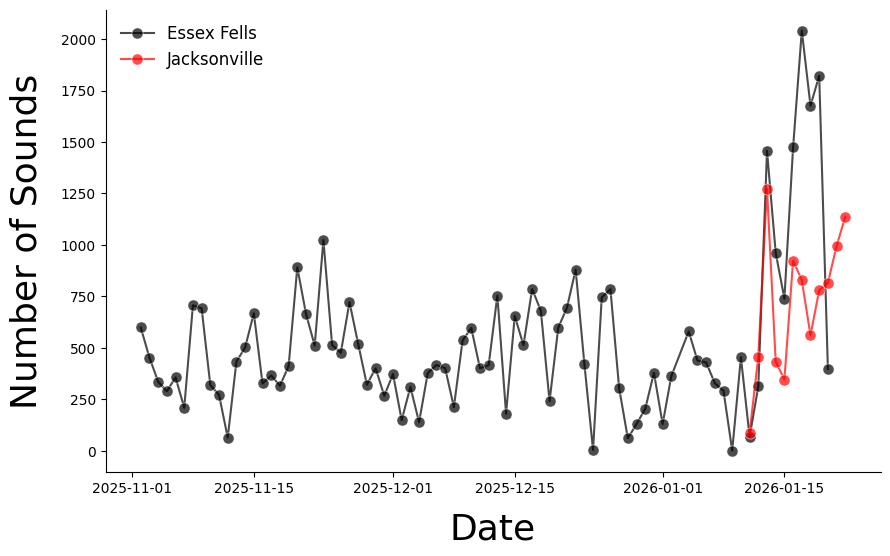

In [40]:
# Plot trends
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    x='date', 
    y='count', 
    hue = 'station_name', 
    data=count_by_date, 
    ax=ax, 
    palette = ['black', 'red'], 
    markers = True,
    marker='o',  
    markersize=8, 
    markeredgewidth=0.5,
    alpha=0.7,
)
ax.set_xlabel('Date', fontsize = 26, labelpad=12)
ax.set_ylabel('Number of Sounds', fontsize = 26, labelpad=12)
plt.legend(fontsize = 12, frameon=False)
sns.despine(top=True, right=True)
plt.show()

In [8]:
study_site_data

,certainty,confidence,id,lat,lon,probability,score,sound_end,sound_start,sound_url,species_common,species_ebird,species_scientific,station_id,station_name,timestamp
0,almost_certain,0.640376,4484313593,40.825611,-74.289009,0.074376,5.549488,3.0,0.0,https://media.birdweather.com/soundscapes/a52a...,Yellow-bellied Sapsucker,yebsap,Sphyrapicus varius,18618,Essex Fells,2025-11-02T03:14:55-08:00
1,almost_certain,0.577612,4484313632,40.825611,-74.289009,0.074376,5.270243,4.5,1.5,https://media.birdweather.com/soundscapes/a52a...,Yellow-bellied Sapsucker,yebsap,Sphyrapicus varius,18618,Essex Fells,2025-11-02T06:14:56-05:00
2,almost_certain,0.936266,4484313667,40.825611,-74.289009,0.074376,6.406513,6.0,3.0,https://media.birdweather.com/soundscapes/a52a...,Yellow-bellied Sapsucker,yebsap,Sphyrapicus varius,18618,Essex Fells,2025-11-02T06:14:58-05:00
3,almost_certain,0.856126,4484313696,40.825611,-74.289009,0.074376,6.222081,7.5,4.5,https://media.birdweather.com/soundscapes/a52a...,Yellow-bellied Sapsucker,yebsap,Sphyrapicus varius,18618,Essex Fells,2025-11-02T06:14:59-05:00
4,almost_certain,0.563025,4484315616,40.825611,-74.289009,0.074376,5.196299,4.5,1.5,https://media.birdweather.com/soundscapes/5dce...,Yellow-bellied Sapsucker,yebsap,Sphyrapicus varius,18618,Essex Fells,2025-11-02T06:15:10-05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49582,almost_certain,0.948713,5287685362,30.097815,-81.611046,0.075914,6.457801,4.5,1.5,https://media.birdweather.com/soundscapes/2197...,Barred Owl,brdowl,Strix varia,21974,Jacksonville,2026-01-23T02:23:26-05:00
49583,almost_certain,0.973093,5287685366,30.097815,-81.611046,0.075914,6.508346,6.0,3.0,https://media.birdweather.com/soundscapes/2197...,Barred Owl,brdowl,Strix varia,21974,Jacksonville,2026-01-23T02:23:28-05:00
49584,almost_certain,0.980200,5287688670,30.097815,-81.611046,0.075914,6.522735,6.0,3.0,https://media.birdweather.com/soundscapes/2197...,Barred Owl,brdowl,Strix varia,21974,Jacksonville,2026-01-23T02:23:53-05:00
49585,almost_certain,0.848508,5287688676,30.097815,-81.611046,0.075914,6.227932,7.5,4.5,https://media.birdweather.com/soundscapes/2197...,Barred Owl,brdowl,Strix varia,21974,Jacksonville,2026-01-23T02:23:54-05:00
